## 1. Setup & Imports

Loading required libraries for data manipulation, numerical operations, and visualization.
`pandas` and `numpy` handle data processing, while `matplotlib` and `seaborn` are used for
creating visualizations throughout this fraud detection analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')

## 2. Load Dataset

Loading the full PaySim transaction dataset (~480 MB) into memory. Since this size is 
manageable for pandas on a modern machine, we load it entirely at once rather than using 
chunking/generators — those techniques are typically needed only when file size exceeds 
available RAM (usually multiple GBs), which isn't the case here.

In [3]:
df = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Data Types & Structure Check

Verifying data types for each column and confirming there are no unexpected type mismatches 
(e.g., numeric columns stored as text). This is a critical first check before any feature 
engineering, especially important here since we have identifier columns (nameOrig, nameDest) 
mixed with numeric transaction data.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## 4. Statistical Summary

Generating descriptive statistics (mean, std, min, max, percentiles) for all numeric columns 
to understand the distribution and identify potential outliers or anomalies — especially 
important here to spot unusual transaction amounts or balance inconsistencies.

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## Step 5: Missing Values Check

Before proceeding further, we check each column for missing (null) values.

**Why is this important?**
- Missing values can distort statistical analysis, visualizations, and model training if left unhandled.
- Training a fraud detection model without addressing missing values can lead to incorrect or biased results.

**What are we expecting?**
Since PaySim is a simulated transactional dataset, it's usually clean — but verifying is a best practice. Never assume, always check.

In [6]:
# Check the count of missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Also check missing values as a percentage for better perspective
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing values percentage:")
print(missing_percentage)

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Missing values percentage:
step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
dtype: float64


## Step 6: Duplicate Records Check

Now we check if there are any duplicate rows in the dataset.

**Why is this important?**
- Duplicate transactions can bias our analysis and model — the same pattern would be counted multiple times, artificially inflating certain trends.
- In real transactional data, true duplicates are rare (each row represents a unique event), but verifying this is still a best practice.

**What are we expecting?**
Since this is simulated transactional data (PaySim), we expect very few or zero duplicates. But we check anyway — never assume.

In [7]:
# Check the total number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

# Also check as a percentage of total rows
duplicate_percentage = (duplicate_count / len(df)) * 100
print("Duplicate percentage:", duplicate_percentage, "%")

Total duplicate rows: 0
Duplicate percentage: 0.0 %


## Step 7: Fraud Distribution by Transaction Type

We now explore how fraud is distributed across different transaction types (PAYMENT, TRANSFER, CASH_OUT, CASH_IN, DEBIT).

**Why is this important?**
- Earlier, we noticed a pattern where fraud occurred only in TRANSFER and CASH_OUT transactions (rows 4 and 5).
- This step confirms whether this pattern holds true across the entire dataset — a key business insight that could shape our entire modeling strategy.

In [8]:
# Count of each transaction type
print("Transaction type counts:")
print(df['type'].value_counts())

# Cross-tabulation: how many fraud vs non-fraud cases per transaction type
print("\nFraud count by transaction type:")
print(df.groupby('type')['isFraud'].sum())

# Percentage of fraud within each transaction type
print("\nFraud rate (%) by transaction type:")
print(df.groupby('type')['isFraud'].mean() * 100)

Transaction type counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud count by transaction type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Fraud rate (%) by transaction type:
type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64


## Step 8: Visualizing Fraud Rate by Transaction Type

We now create a bar chart to visually confirm the fraud rate pattern across transaction types.

**Why is this important?**
- Numbers in a table are useful, but a visual makes the pattern immediately obvious — especially for presentations or reports.
- This chart will clearly show that fraud is concentrated only in TRANSFER and CASH_OUT transactions.

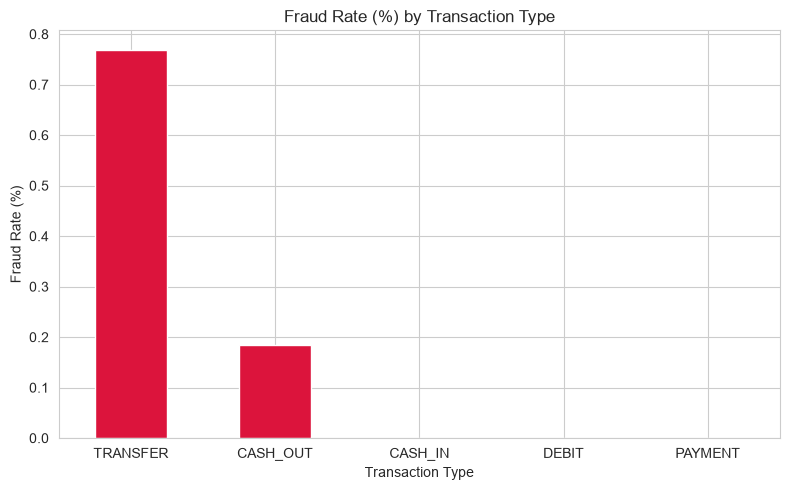

In [9]:
import matplotlib.pyplot as plt

# Calculate fraud rate (%) per transaction type
fraud_rate_by_type = df.groupby('type')['isFraud'].mean() * 100

# Create bar chart
plt.figure(figsize=(8, 5))
fraud_rate_by_type.sort_values(ascending=False).plot(kind='bar', color='crimson')

plt.title('Fraud Rate (%) by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 9: Balance Inconsistency Analysis

We now investigate a suspicious pattern noticed earlier — cases where the sender's balance doesn't update correctly after a transaction.

**Why is this important?**
- Earlier, we saw a case where `oldbalanceOrg = 181` and `newbalanceOrig = 0` in a fraud transaction — meaning the entire balance was wiped out.
- In legitimate transactions, the math should hold: `newbalanceOrig = oldbalanceOrg - amount`.
- When this equation doesn't hold (a mismatch/error), it can be a strong signal of fraudulent activity — this is a classic feature engineering insight used by real fraud analysts.

In [10]:
# Calculate the expected new balance based on old balance and transaction amount
df['expected_newbalanceOrig'] = df['oldbalanceOrg'] - df['amount']

# Calculate the difference between actual and expected new balance
df['balance_diff_orig'] = df['newbalanceOrig'] - df['expected_newbalanceOrig']

# Check how many transactions have a mismatch (non-zero difference)
mismatch_count = (df['balance_diff_orig'] != 0).sum()
print("Total transactions with balance mismatch:", mismatch_count)
print("Percentage of total:", (mismatch_count / len(df)) * 100, "%")

# Compare fraud rate in mismatched vs matched transactions
print("\nFraud rate in mismatched balance transactions:")
print(df[df['balance_diff_orig'] != 0]['isFraud'].mean() * 100, "%")

print("\nFraud rate in matched balance transactions:")
print(df[df['balance_diff_orig'] == 0]['isFraud'].mean() * 100, "%")

Total transactions with balance mismatch: 5413997
Percentage of total: 85.09068591240715 %

Fraud rate in mismatched balance transactions:
0.002345771525178163 %

Fraud rate in matched balance transactions:
0.8523934165627441 %


## Step 10: Balance Mismatch by Transaction Type

We investigate whether the balance mismatch is concentrated in specific transaction types, or spread evenly across all types.

**Why is this important?**
- If mismatch happens mostly in types where `nameDest` is a merchant (M-prefix) — like PAYMENT — this would confirm it's a data generation quirk, not a fraud signal.
- This helps us understand whether `balance_diff_orig` is a useful feature at all, or if it needs to be refined.

In [11]:
# Check mismatch percentage by transaction type
mismatch_by_type = df.groupby('type')['balance_diff_orig'].apply(lambda x: (x != 0).mean() * 100)
print("Mismatch percentage by transaction type:")
print(mismatch_by_type)

Mismatch percentage by transaction type:
type
CASH_IN     100.000000
CASH_OUT     92.920492
DEBIT        38.330276
PAYMENT      65.188113
TRANSFER     97.055407
Name: balance_diff_orig, dtype: float64


## Step 11: Balance Inconsistency Analysis (Receiver Side)

We now perform a similar check on the receiver's balance (`oldbalanceDest`, `newbalanceDest`) to see if it holds better predictive value for fraud than the sender's balance did.

**Why is this important?**
- Just like we checked if sender's balance updates correctly (`newbalanceOrig = oldbalanceOrg - amount`), we now check if receiver's balance updates correctly (`newbalanceDest = oldbalanceDest + amount`).
- This may reveal a different pattern, especially since merchants (M-prefix `nameDest`) are known to not have balance tracked in PaySim — which could explain part of the earlier issue.

In [12]:
# Calculate the expected new balance for the receiver
df['expected_newbalanceDest'] = df['oldbalanceDest'] + df['amount']

# Calculate the difference between actual and expected new balance
df['balance_diff_dest'] = df['newbalanceDest'] - df['expected_newbalanceDest']

# Check overall mismatch percentage
mismatch_count_dest = (df['balance_diff_dest'] != 0).sum()
print("Total transactions with receiver balance mismatch:", mismatch_count_dest)
print("Percentage of total:", (mismatch_count_dest / len(df)) * 100, "%")

# Compare fraud rate in mismatched vs matched transactions (receiver side)
print("\nFraud rate in mismatched receiver balance transactions:")
print(df[df['balance_diff_dest'] != 0]['isFraud'].mean() * 100, "%")

print("\nFraud rate in matched receiver balance transactions:")
print(df[df['balance_diff_dest'] == 0]['isFraud'].mean() * 100, "%")

# Also check mismatch percentage by transaction type
print("\nMismatch percentage by transaction type (receiver side):")
print(df.groupby('type')['balance_diff_dest'].apply(lambda x: (x != 0).mean() * 100))

Total transactions with receiver balance mismatch: 4736674
Percentage of total: 74.44533855550071 %

Fraud rate in mismatched receiver balance transactions:
0.11239954449050113 %

Fraud rate in matched receiver balance transactions:
0.17768117760368426 %

Mismatch percentage by transaction type (receiver side):
type
CASH_IN     100.000000
CASH_OUT     41.734749
DEBIT        47.574339
PAYMENT     100.000000
TRANSFER     43.603880
Name: balance_diff_dest, dtype: float64


## Step 12: Transaction Amount Distribution — Fraud vs Non-Fraud

We now compare the transaction `amount` between fraud and non-fraud transactions to see if fraudulent transactions tend to involve different (typically higher) amounts.

**Why is this important?**
- Earlier, we saw `amount` had a highly skewed distribution (std >> mean), with some extreme outliers.
- If fraud transactions consistently have higher (or specific) amounts, this becomes a very useful feature for our model.

In [13]:
# Compare amount statistics for fraud vs non-fraud transactions
print("Amount statistics for FRAUD transactions:")
print(df[df['isFraud'] == 1]['amount'].describe())

print("\nAmount statistics for NON-FRAUD transactions:")
print(df[df['isFraud'] == 0]['amount'].describe())

Amount statistics for FRAUD transactions:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

Amount statistics for NON-FRAUD transactions:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64


## Step 13: Visualizing Amount Distribution — Fraud vs Non-Fraud

We create a boxplot to visually compare the transaction amount distribution between fraud and non-fraud transactions.

**Why is this important?**
- The statistics confirmed fraud transactions tend to have higher amounts — a boxplot will make this pattern visually clear, including outliers.
- Since amount has extreme outliers (as seen earlier), we'll use a log scale to make the comparison readable.

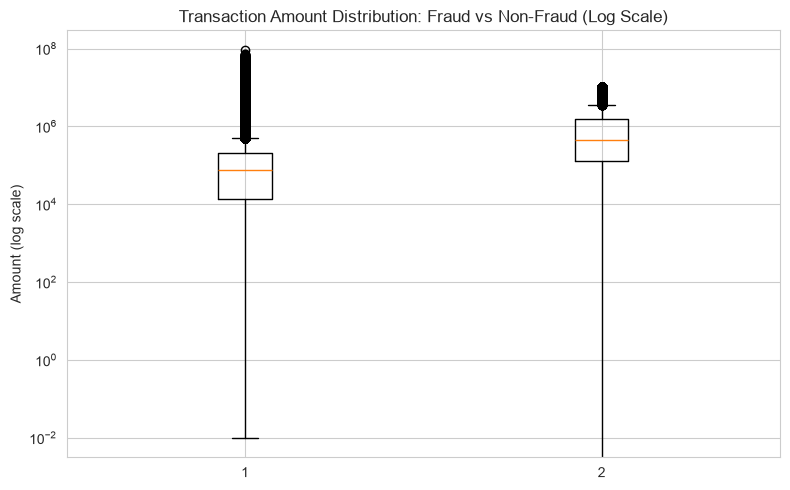

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Set pandas display option so numbers show normally instead of scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

plt.figure(figsize=(8, 5))

# Boxplot: amount by isFraud, using log scale because of extreme outliers
data_to_plot = [df[df['isFraud'] == 0]['amount'], df[df['isFraud'] == 1]['amount']]

plt.boxplot(data_to_plot, label=['Non-Fraud', 'Fraud'])
plt.yscale('log')  # log scale because amount has huge outliers
plt.title('Transaction Amount Distribution: Fraud vs Non-Fraud (Log Scale)')
plt.ylabel('Amount (log scale)')
plt.tight_layout()
plt.show()

## Step 14: Fraud Pattern Over Time (step column)

We now explore whether fraud transactions are concentrated in specific time periods, or spread evenly throughout the simulation (744 hours = 31 days).

**Why is this important?**
- If fraud clusters around certain hours (e.g., late night, specific days), this becomes a valuable time-based feature for our model.
- It can also reveal behavioral patterns — e.g., fraudsters may act during low-monitoring hours.

Step statistics for FRAUD transactions:
count   8213.00
mean     368.41
std      216.39
min        1.00
25%      181.00
50%      367.00
75%      558.00
max      743.00
Name: step, dtype: float64

Step statistics for NON-FRAUD transactions:
count   6354407.00
mean        243.24
std         142.14
min           1.00
25%         156.00
50%         239.00
75%         334.00
max         718.00
Name: step, dtype: float64


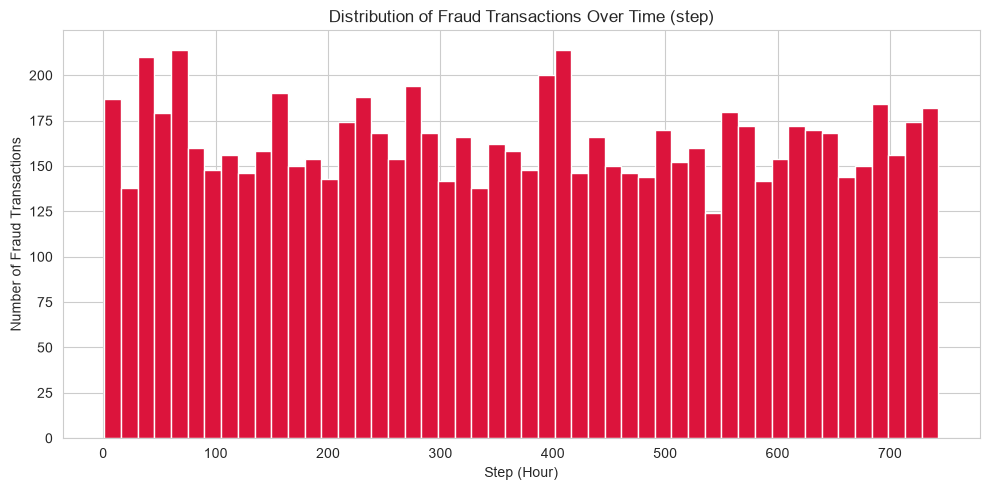

In [16]:
import matplotlib.pyplot as plt

# Compare average 'step' for fraud vs non-fraud
print("Step statistics for FRAUD transactions:")
print(df[df['isFraud'] == 1]['step'].describe())

print("\nStep statistics for NON-FRAUD transactions:")
print(df[df['isFraud'] == 0]['step'].describe())

# Plot distribution of fraud transactions over time (step)
plt.figure(figsize=(10, 5))
df[df['isFraud'] == 1]['step'].hist(bins=50, color='crimson')
plt.title('Distribution of Fraud Transactions Over Time (step)')
plt.xlabel('Step (Hour)')
plt.ylabel('Number of Fraud Transactions')
plt.tight_layout()
plt.show()

## Step 15: Existing Detection System Check (isFlaggedFraud)

We now examine how well the existing rule-based system (`isFlaggedFraud`) performs at catching actual fraud, compared to our target variable `isFraud`.

**Why is this important?**
- This shows us the baseline we're improving upon — how many actual frauds the current system misses.
- It also helps confirm whether `isFlaggedFraud` should be used as a feature, or excluded (since it might cause data leakage if it was set using future/fraud-related information).

In [17]:
# Total flagged vs total actual fraud
print("Total isFlaggedFraud = 1:", df['isFlaggedFraud'].sum())
print("Total isFraud = 1:", df['isFraud'].sum())

# Cross-tabulation: how many flagged transactions were actually fraud
print("\nCross-tab of isFraud vs isFlaggedFraud:")
print(pd.crosstab(df['isFraud'], df['isFlaggedFraud']))

Total isFlaggedFraud = 1: 16
Total isFraud = 1: 8213

Cross-tab of isFraud vs isFlaggedFraud:
isFlaggedFraud        0   1
isFraud                    
0               6354407   0
1                  8197  16
